# Irrigation Need Prediction — Multi-Class Classification

## Problem Statement

Predicting irrigation requirements for agricultural fields is critical for
optimizing water usage and preventing crop loss. Under-irrigation leads to
crop stress and yield loss; over-irrigation wastes scarce water resources
and can cause soil degradation. This project builds a classification model
to predict whether a field's irrigation need is **Low**, **Medium**, or
**High** based on soil conditions, weather data, crop characteristics,
and farming practices.

## Why This Matters

The cost of prediction errors is asymmetric: failing to identify a
high-need field (false negative on High) can result in crop death, while
a false alarm (false positive on High) only costs an unnecessary field
visit. This asymmetry drives every modeling decision in this project —
from metric selection to class weighting to threshold interpretation.

## Dataset

- **10,000 samples** across agricultural regions
- **11 numerical features**: soil properties (pH, moisture, organic carbon,
  electrical conductivity), weather (temperature, humidity, rainfall,
  sunlight, wind speed), and field characteristics (area, previous irrigation)
- **8 categorical features**: soil type, crop type, growth stage, season,
  irrigation type, water source, mulching, region
- **Target**: `Irrigation_Need` — 3 classes (Low: ~59%, Medium: ~38%, High: ~3%)
- **Key challenge**: severe class imbalance on the most critical class (High)

## Analytical Approach

1. **EDA** — identify which features show marginal separation across classes,
   form hypotheses about predictive power and potential interactions
2. **Baseline with LogisticRegression** — isolate the effects of stratified
   CV and class weighting through a controlled 2×2 ablation study
3. **Multi-model comparison** — benchmark KNN, DecisionTree, RandomForest,
   and LogisticRegression through unified GridSearchCV
4. **Interpretability** — validate model logic against domain knowledge
   using feature importance and SHAP analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, confusion_matrix
!pip install shap
import shap

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/python/projects /irrigaton water requirement prediction/irrigation_prediction.csv")

In [ ]:
cat_cols = ['Soil_Type','Crop_Type', 'Crop_Growth_Stage',
       'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

tgt_col = ["Irrigation_Need"]

num_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon',
       'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm',
       'Sunlight_Hours', 'Wind_Speed_kmh','Field_Area_hectare','Previous_Irrigation_mm']

# **Understanding Data**

In [ ]:
df.info()

# no null values observed
# values are stored in correct dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Soil_Type                10000 non-null  object 
 1   Soil_pH                  10000 non-null  float64
 2   Soil_Moisture            10000 non-null  float64
 3   Organic_Carbon           10000 non-null  float64
 4   Electrical_Conductivity  10000 non-null  float64
 5   Temperature_C            10000 non-null  float64
 6   Humidity                 10000 non-null  float64
 7   Rainfall_mm              10000 non-null  float64
 8   Sunlight_Hours           10000 non-null  float64
 9   Wind_Speed_kmh           10000 non-null  float64
 10  Crop_Type                10000 non-null  object 
 11  Crop_Growth_Stage        10000 non-null  object 
 12  Season                   10000 non-null  object 
 13  Irrigation_Type          10000 non-null  object 
 14  Water_Source           

In [ ]:
df.describe()

# an observable difference in the range of the features

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [ ]:
for col in df[cat_cols].columns:
  print("-"*50)
  print(df[col].value_counts(normalize = True)*100, "/n")

# understanding the distribution of cat_cols frequency
# fairly equally distributed

--------------------------------------------------
Soil_Type
Sandy    25.36
Silt     25.01
Loamy    24.86
Clay     24.77
Name: proportion, dtype: float64 /n
--------------------------------------------------
Crop_Type
Rice         17.11
Maize        16.94
Sugarcane    16.78
Potato       16.63
Wheat        16.59
Cotton       15.95
Name: proportion, dtype: float64 /n
--------------------------------------------------
Crop_Growth_Stage
Harvest       25.81
Vegetative    25.21
Flowering     24.65
Sowing        24.33
Name: proportion, dtype: float64 /n
--------------------------------------------------
Season
Rabi      33.83
Kharif    33.62
Zaid      32.55
Name: proportion, dtype: float64 /n
--------------------------------------------------
Irrigation_Type
Sprinkler    25.27
Rainfed      25.11
Drip         24.95
Canal        24.67
Name: proportion, dtype: float64 /n
--------------------------------------------------
Water_Source
River          25.28
Reservoir      25.13
Rainwater      24.97

In [ ]:
df[tgt_col].value_counts(normalize = True)*100

# frequency distribution of tgt variable
# class imbalance

,proportion
Irrigation_Need,
Low,58.64
Medium,38.00
High,3.36


# **EDA**

In [ ]:
num_cols

['Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Field_Area_hectare',
 'Previous_Irrigation_mm']

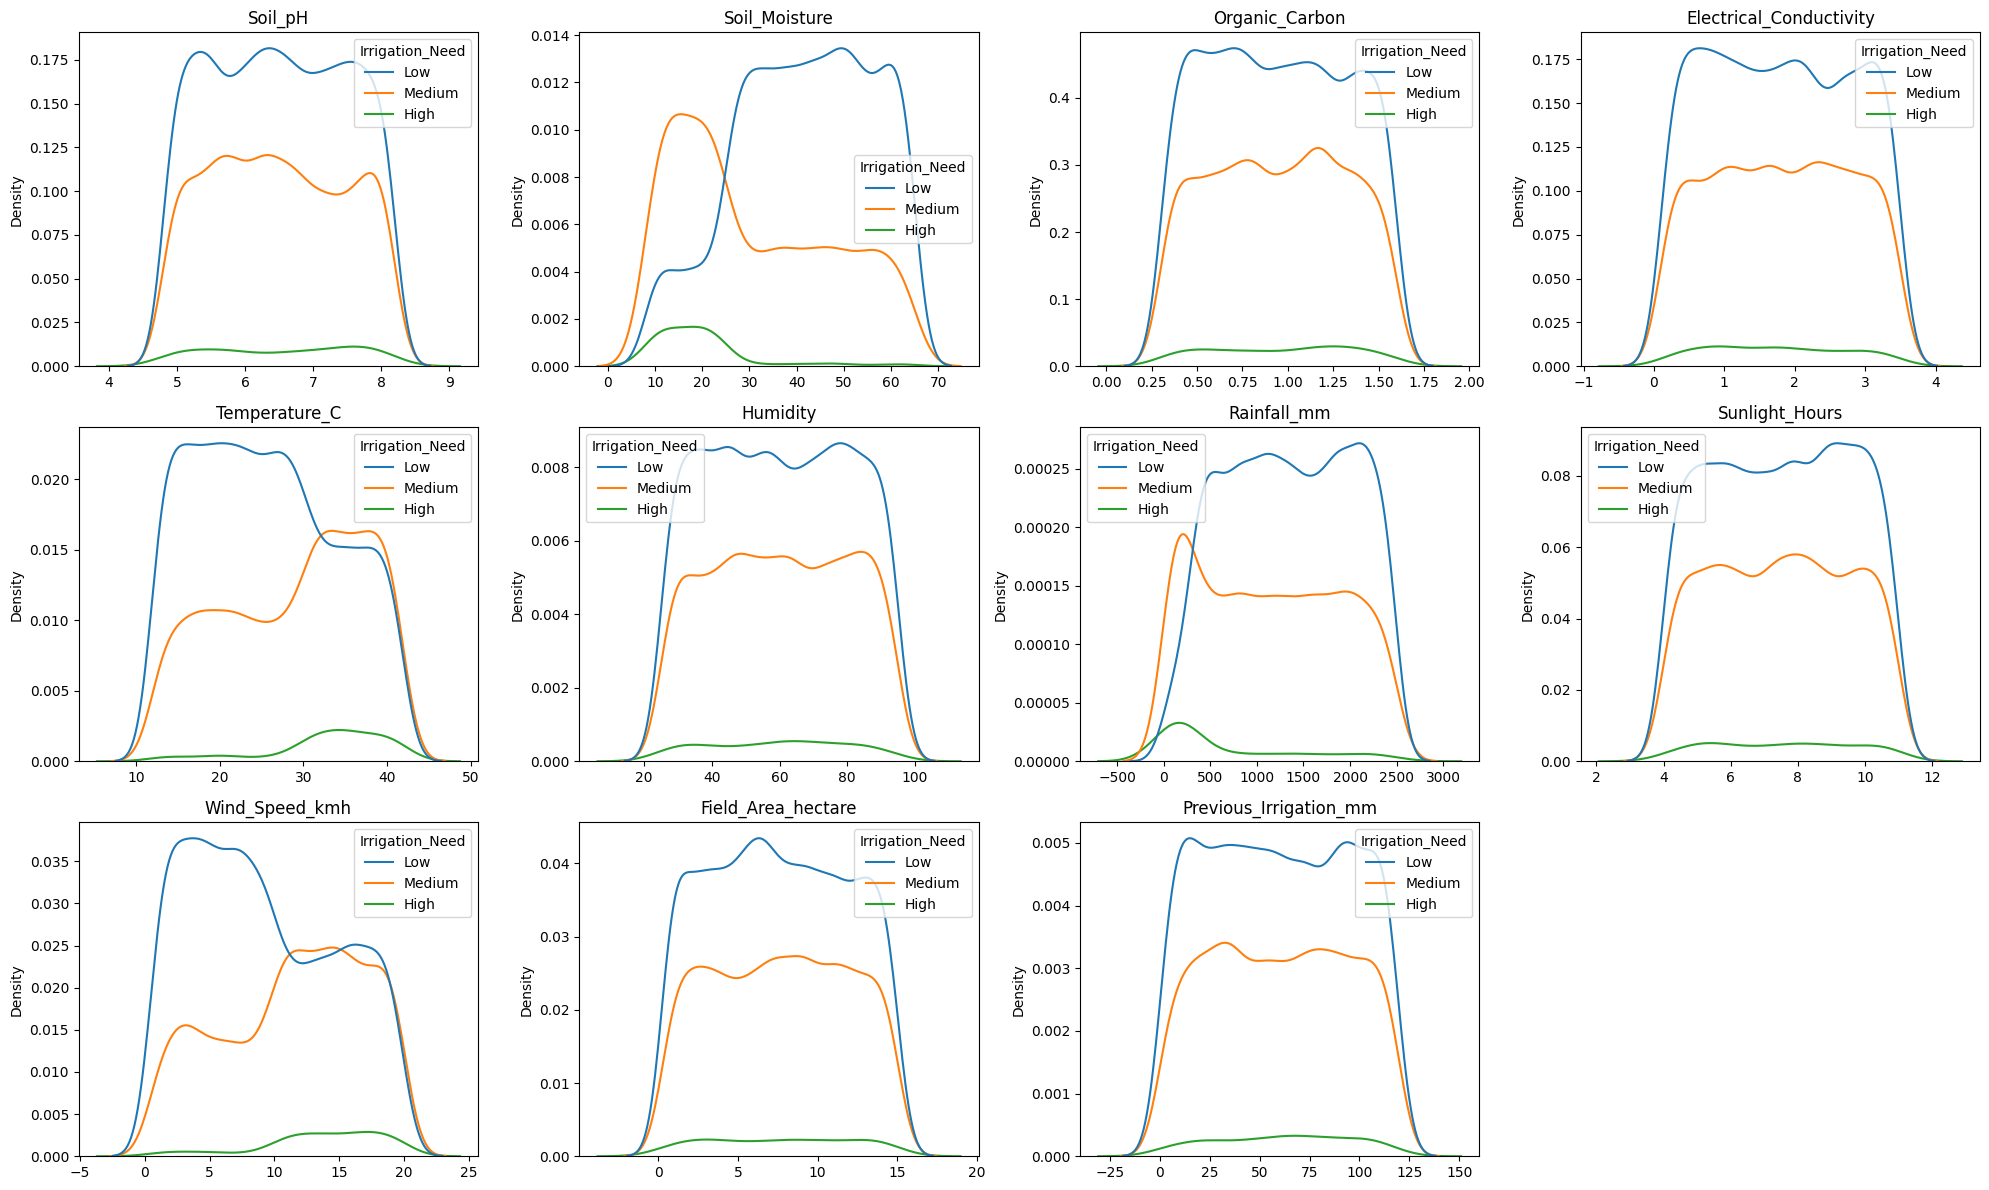

In [ ]:
fig, axes = plt.subplots(ncols = 4, nrows = 3, figsize = (20,12))
axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.kdeplot(df, x = col, hue = "Irrigation_Need", ax = axes[i])
  axes[i].set_title(col)
  axes[i].set_xlabel("")

axes[11].set_visible(False)
plt.tight_layout()
plt.show()

# from the plot - 3 features shows clear visual separation between the classes
# features are - soil moisture, temperature, wind_speed

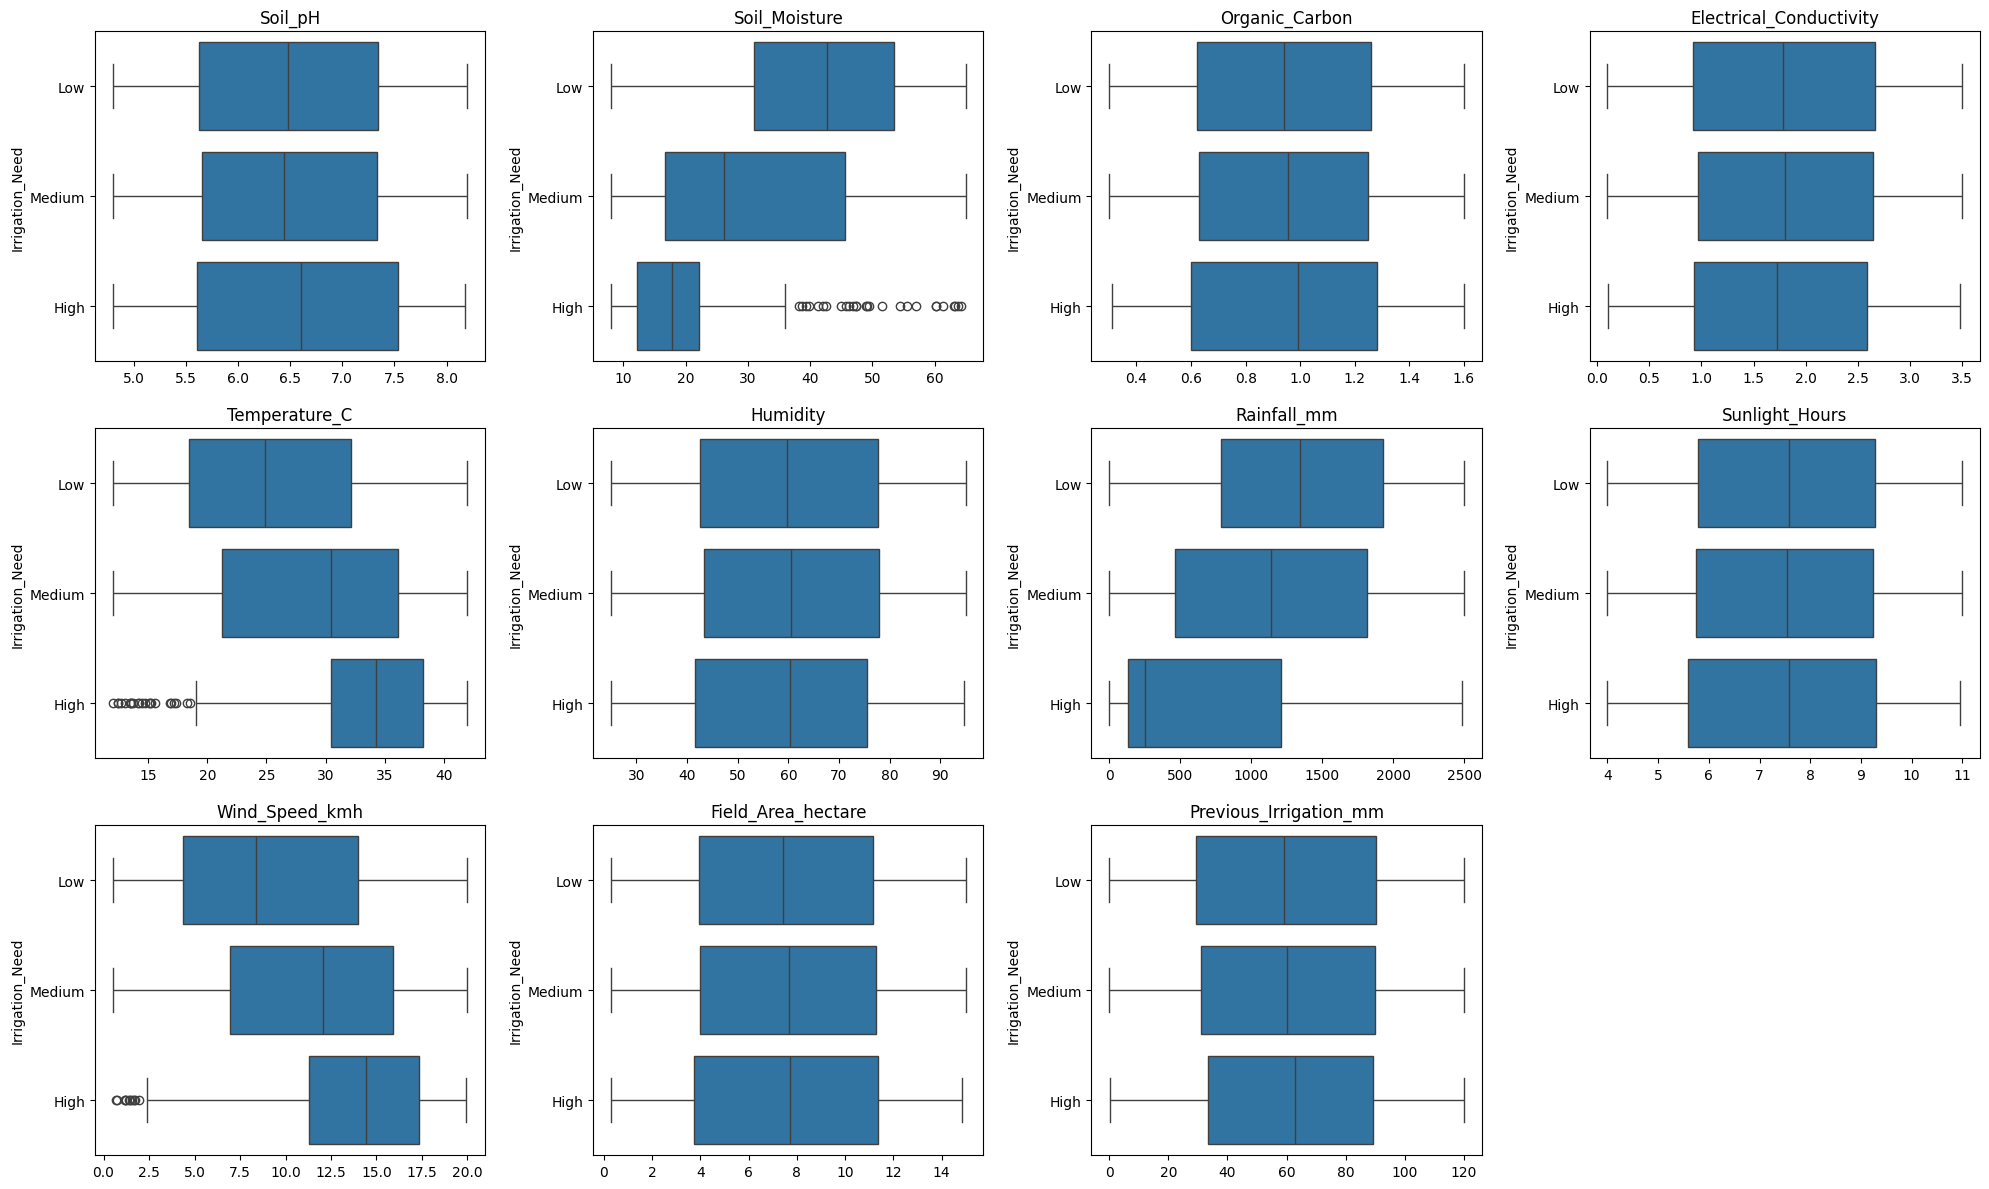

In [ ]:
fig, axes = plt.subplots(ncols = 4, nrows = 3, figsize = (20,12))
axes = axes.flatten()

for i,col in enumerate(num_cols):
  sns.boxplot(df, x = col, y = "Irrigation_Need", ax = axes[i])
  axes[i].set_title(col)
  axes[i].set_xlabel("")

axes[11].set_visible(False)
plt.tight_layout(h_pad = 1.5, w_pad = 1.5)
plt.show()

# the same observation can be more clearly visualized here in box plot

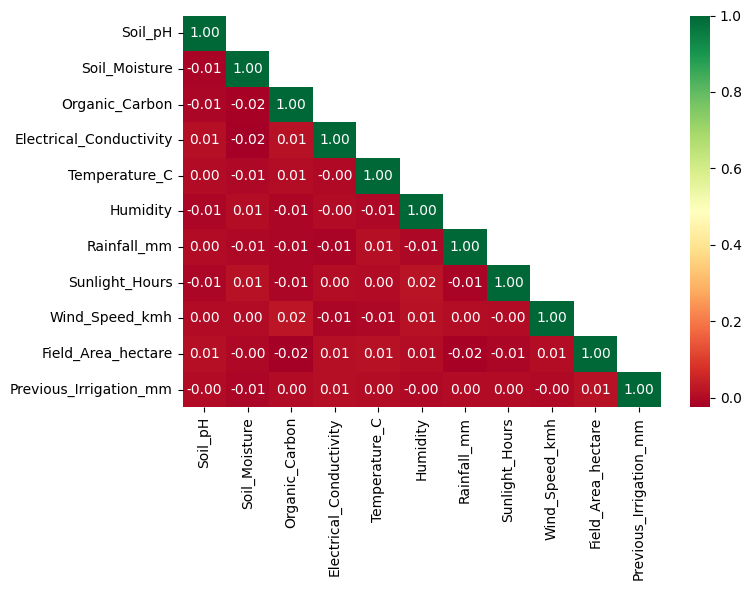

In [ ]:
fig,ax = plt.subplots(figsize = (8,6))

corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype = bool), k = 1)

sns.heatmap(corr, annot = True, cmap = "RdYlGn", fmt = ".2f", mask = mask)

plt.tight_layout()
plt.show()

# none of the features show high correlation

In [ ]:
cat_cols

['Soil_Type',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Mulching_Used',
 'Region']

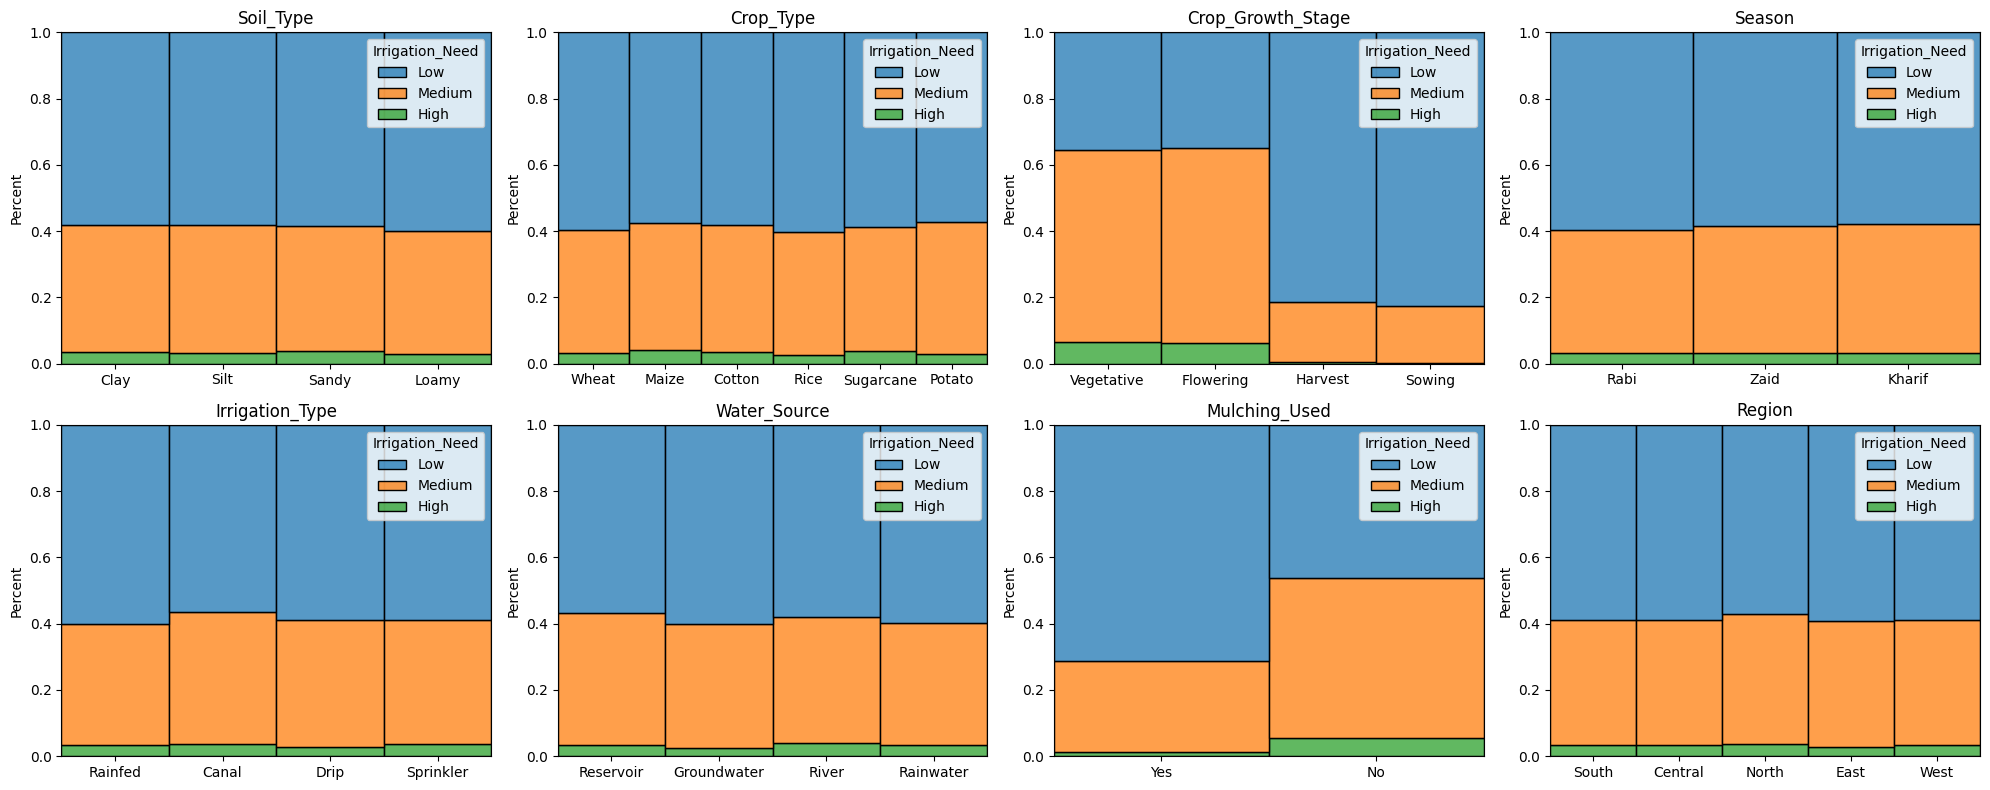

In [ ]:
fig, axes = plt.subplots(ncols = 4, nrows = 2, figsize = (20,8))
axes = axes.flatten()

for i,col in enumerate(cat_cols):
  sns.histplot(df, x = col,hue = "Irrigation_Need",ax = axes[i],
               stat = "percent", multiple = "fill")

  axes[i].set_title(col)
  axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

# Crop growth stage and Mulching are strong categorical predictors.
# though rest show marginal difference - doesnt mean they are useless,\
# there may be interactions between features that single plots cannot reveal.


# **Encoding**

In [ ]:
df_enc = pd.get_dummies(df, columns = cat_cols, drop_first = True)

# **Logistic Regression Model**

Since there exists class imbalance, lets see the affect of class weight and stratified fold on the model perfromance.

1. Class_Weight changes how the model learns from a given dataset.
2. Stratification changes what dataset the model learn from(ensures rare classes are present and proportional)
3. Both should improve minority class performance, though through different mechanism

In [ ]:
x = df_enc.drop(columns = tgt_col)
y = df_enc["Irrigation_Need"].to_numpy()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, stratify = y, random_state = 11)

In [ ]:
grid = {
    "simple" : {"model__C" : [0.001,0.01,0.1,1,10]},
    "weight" : {"model__C": [0.001, 0.01, 0.1, 1 ,10], "model__class_weight": ["balanced"]}
}

folds = {
    "strat" : StratifiedKFold(n_splits =5, shuffle = True, random_state = 11),
    "kfold" : KFold(n_splits = 5, shuffle = True, random_state = 11)
}

scaler = ColumnTransformer( transformers = [
    ("scaler", StandardScaler(), num_cols)],
    remainder = "passthrough" )

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", LogisticRegression(random_state = 11))
])



In [ ]:
# simple -
grid_simple = GridSearchCV(pipeline, grid["simple"], cv = folds["kfold"], scoring = "f1_macro")
grid_simple.fit(x_train, y_train)
y_simple = grid_simple.predict(x_test)
report_simple = classification_report(y_test, y_simple, output_dict = True)

results_simple = pd.DataFrame(report_simple).reset_index()

In [ ]:
# Stratification

grid_strat = GridSearchCV(pipeline, grid["simple"], cv = folds["strat"], scoring = "f1_macro")
grid_strat.fit(x_train, y_train)
y_strat = grid_strat.predict(x_test)
report_strat = classification_report(y_test, y_strat, output_dict = True)

results_strat = pd.DataFrame(report_strat).reset_index()

In [ ]:
# class_weight

grid_weight = GridSearchCV(pipeline, grid["weight"], cv = folds["kfold"], scoring = "f1_macro")
grid_weight.fit(x_train, y_train)
y_weight = grid_weight.predict(x_test)
report_weight = classification_report(y_test, y_weight, output_dict = True)

results_weight = pd.DataFrame(report_weight).reset_index()

In [ ]:
# Both

grid_both = GridSearchCV(pipeline, grid["weight"], cv = folds["strat"], scoring = "f1_macro")
grid_both.fit(x_train, y_train)
y_both = grid_both.predict(x_test)
report_both = classification_report(y_test, y_both, output_dict = True)

results_both = pd.DataFrame(report_both).reset_index()

In [ ]:
print(f" Logistic Regression Model(Balanced weight) score on Test set {grid_both.score(x_test, y_test):.3f}")

 Logistic Regression Model(Balanced weight) score on Test set 0.676


In [ ]:
results_simple["method"] = "simple"
results_strat["method"] = "stratification"
results_weight["method"] = "weights"
results_both["method"] = "both"

In [ ]:
results = pd.concat([results_simple, results_strat, results_weight, results_both], axis = 0)
results = results.rename(columns = {"index":"metrics"})

results

,metrics,High,Low,Medium,accuracy,macro avg,weighted avg,method
0,precision,0.637931,0.866131,0.768987,0.8240,0.757683,0.821549,simple
1,recall,0.440476,0.882674,0.767368,0.8240,0.696840,0.824000,simple
2,f1-score,0.521127,0.874324,0.768177,0.8240,0.721209,0.822121,simple
3,support,84.000000,1466.000000,950.000000,0.8240,2500.000000,2500.000000,simple
0,precision,0.637931,0.866131,0.768987,0.8240,0.757683,0.821549,stratification
1,recall,0.440476,0.882674,0.767368,0.8240,0.696840,0.824000,stratification
2,f1-score,0.521127,0.874324,0.768177,0.8240,0.721209,0.822121,stratification
3,support,84.000000,1466.000000,950.000000,0.8240,2500.000000,2500.000000,stratification
0,precision,0.321267,0.896703,0.721007,0.7816,0.646326,0.810604,weights
1,recall,0.845238,0.834925,0.693684,0.7816,0.791282,0.781600,weights


In [ ]:
result_melt = results.loc[ results["metrics"] != "support"].melt(id_vars = ["metrics", "method"], var_name = "label", value_name = "score")

result_melt.head()

,metrics,method,label,score
0,precision,simple,High,0.637931
1,recall,simple,High,0.440476
2,f1-score,simple,High,0.521127
3,precision,stratification,High,0.637931
4,recall,stratification,High,0.440476


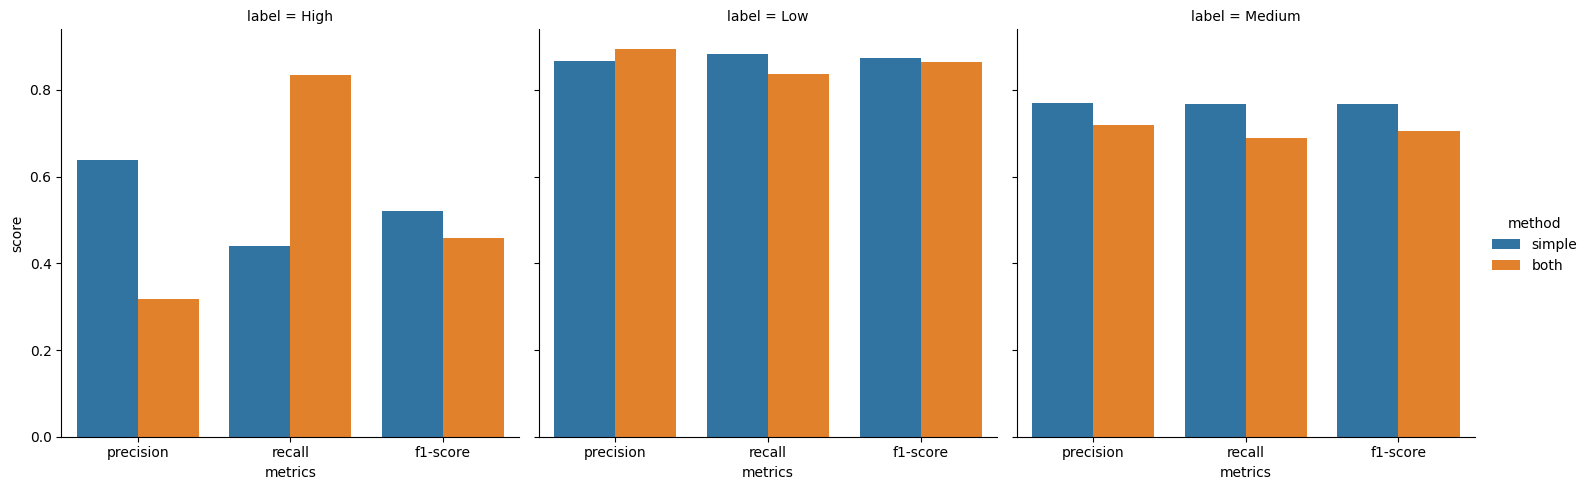

In [ ]:
sns.catplot(result_melt.loc[(result_melt["method"].isin(["simple", "both"])) & (result_melt["label"].isin(["High", "Low", "Medium"]))],
            x = "metrics",y = "score", col = "label", kind = "bar", hue = "method")


plt.show()

class_weight = balanced.

On High class - the recall gets nearly doubled at the cost of halving the precision. The F1 went down from 0.52 to 0.47 and overall accuracy dropped from 0.842 to 0.782.

Which to choose?
The answer depends on which cost is higher - FN or FP.

Is it costly to send manpower to the fields with no need for it..(False Positive)? OR Is it costly to miss sending manpower to field, leading to crop dying(False negative).

Most probably it will be costlier to not send someone to field, thus we will rather high recall than precision.(Rather have water stressed fields than dry field)


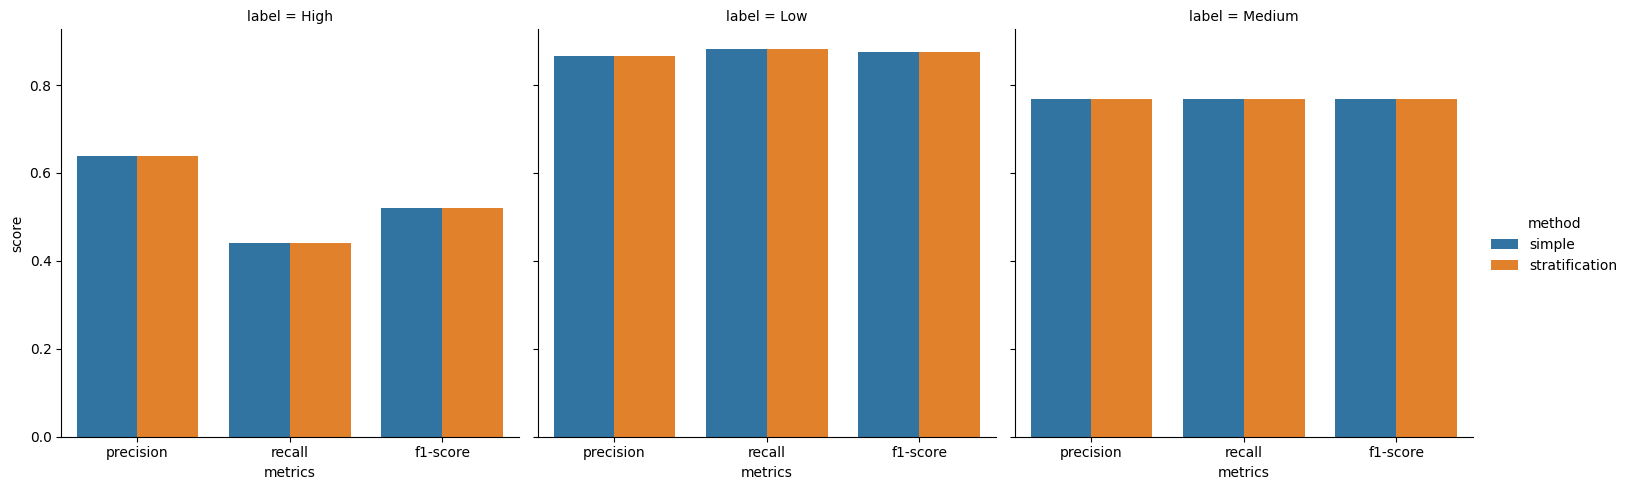

In [ ]:
sns.catplot(result_melt.loc[(result_melt["method"].isin(["simple", "stratification"])) & (result_melt["label"].isin(["High", "Low", "Medium"]))],
            x = "metrics",y = "score", col = "label", kind = "bar", hue = "method")


plt.show()

Stratified K-Fold did not improve performance over standard K-Fold on this dataset, likely because the minority class (3%) was still numerous enough in absolute terms (50 samples per fold) to be reliably represented under random splitting. Stratification remains best practice as a safeguard, but the marginal benefit depends on absolute minority class count, not just proportion.

# **Learnings**

1. Stratified vs standard K-Fold produced identical results on this dataset. The minority class (3%) was numerous enough in absolute terms that random folding consistently included it. Stratification remains best practice as a safeguard but provided no measurable lift here.


2. class_weight='balanced' dramatically improved minority-class recall (0.44 → 0.85) at the cost of precision (0.64 → 0.32) and overall accuracy (0.82 → 0.78). Macro-F1 slightly favored the unweighted model, but this metric does not reflect the real-world cost structure of irrigation decisions, where failing to identify a water-stressed field (false negative on High) is substantially more costly than a false alarm.


3. Metric selection drives model selection. Re-running GridSearchCV with scoring='recall_macro' produces a different "best" model, highlighting that scoring choice in CV is itself a modeling decision that should be tied to business cost asymmetry

# **Models**

In [ ]:
param_grid = [
    {"scaler":[scaler], "model":[KNeighborsClassifier()], "model__n_neighbors": [3,5,7,9]},
    {"scaler":[None], "model": [DecisionTreeClassifier(random_state = 13, class_weight = "balanced")], "model__max_depth": [3,5,7,9]},
    {"scaler": [None], "model": [RandomForestClassifier(random_state = 13, class_weight = "balanced")], "model__max_depth":[3,5,7,9], "model__n_estimators":[50,100,150,200]},
    {"scaler":[scaler], "model":[LogisticRegression(random_state = 13, class_weight = "balanced")], "model__C": [0.01, 0.1, 1, 10]}
]

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 13)

grid = GridSearchCV( pipeline, cv = cv, param_grid = param_grid, scoring = "f1_macro")
grid.fit(x_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=13, shuffle=True),
             estimator=Pipeline(steps=[('scaler',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('scaler',
                                                                         StandardScaler(),
                                                                         ['Soil_pH',
                                                                          'Soil_Moisture',
                                                                          'Organic_Carbon',
                                                                          'Electrical_Conductivity',
                                                                          'Temperature_C',
                                                                          'Humidity',
                                                                          'Rainfall_mm',
                                                                          'Sunlight_Hours',
                                                                          'Wind_Speed_kmh',
                                                                          'Field_Area_h...
                                                       random_state=13)],
                          'model__C': [0.01, 0.1, 1, 10],
                          'scaler': [ColumnTransformer(remainder='passthrough',
                                                       transformers=[('scaler',
                                                                      StandardScaler(),
                                                                      ['Soil_pH',
                                                                       'Soil_Moisture',
                                                                       'Organic_Carbon',
                                                                       'Electrical_Conductivity',
                                                                       'Temperature_C',
                                                                       'Humidity',
                                                                       'Rainfall_mm',
                                                                       'Sunlight_Hours',
                                                                       'Wind_Speed_kmh',
                                                                       'Field_Area_hectare',
                                                                       'Previous_Irrigation_mm'])])]}],
             scoring='f1_macro')

In [ ]:
print(f"Best Model {str(grid.best_params_)}")
print(f"Best Score on Train set {grid.best_score_:.3f}")
print(f"Score on Test set {grid.score(x_test, y_test):.3f} ")


Best Model {'model': DecisionTreeClassifier(class_weight='balanced', random_state=13), 'model__max_depth': 9, 'scaler': None}
Best Score on Train set 0.972
Score on Test set 0.984 


As we can see a Decision Tree model performed much better than a LogisticRegression model.Showing that it is better able to understand the intricasies of the feature variables.(Discussed Under EDA section - not to delete the cat columns - that showed marginal differences across the tgt variables)


Decision Tree macro f1 score = 0.984

Logistic Regression macro f1 score = *0.676*

In [ ]:
y_pred = grid.predict(x_test)

report = classification_report(y_test, y_pred, output_dict = True)
cm = confusion_matrix(y_test, y_pred, normalize = "true",
                                    labels = ["High", "Medium", "Low"])

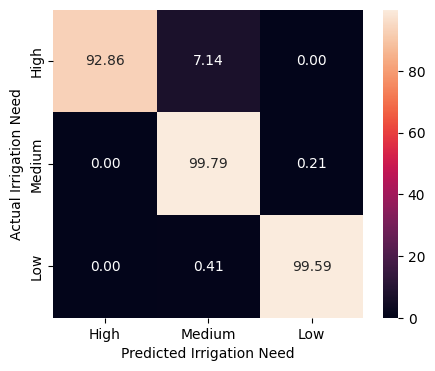

In [ ]:
plt.figure(figsize=(5, 4))

sns.heatmap(cm*100, annot = True, fmt = ".2f",
            xticklabels = ["High", "Medium", "Low"],
            yticklabels = ["High", "Medium", "Low"])

plt.xlabel("Predicted Irrigation Need")
plt.ylabel("Actual Irrigation Need")
plt.show()

The above confusion Matrix heatmap is proportional along the rows.

From the plot, we can see that for medium and low irrigation need - the model correclty predicted the requirement 99% of the time. As small percentage was shifted to either the low or medium irrigiation need.

For the High irrigation need - It correctly predicted 92.86% of the time and 7.14% of the time it did fall- it categorized the need under medium need, thus gracefully degrading the severity, but not catastrophically by flipping high to low need.

A single score does tell a story, but it fails to paint a full picture of where and how we are going wrong. A Confusion matrix help in bridging that gap.

In [ ]:
importance = grid.best_estimator_.named_steps["model"].feature_importances_


df_feature = pd.DataFrame({
    "features": x_train.columns,
    "importance": np.round(importance,4)
}).sort_values(by = "importance", ascending = False)

df_feature.head()

,features,importance
1,Soil_Moisture,0.2072
4,Temperature_C,0.1632
8,Wind_Speed_kmh,0.1550
30,Mulching_Used_Yes,0.1384
6,Rainfall_mm,0.1266


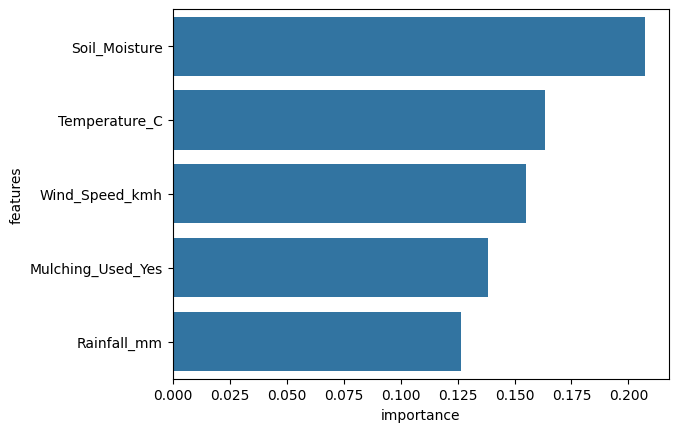

In [ ]:
sns.barplot(df_feature.head(), y = "features", x = "importance")
plt.show()

Feature importance analysis reveals that the top predictors — Soil_Moisture, Temperature, Wind_Speed, Mulching, and Rainfall . The alignment between model behavior and the earlier EDA analysis increases confidence that the model is learning genuine relationships rather than spurious correlations. Crop_Growth_Stage, which showed the strongest categorical signal in EDA, appears lower in the ranking — likely due to importance fragmentation across one-hot encoded dummy variables rather than genuine irrelevance.

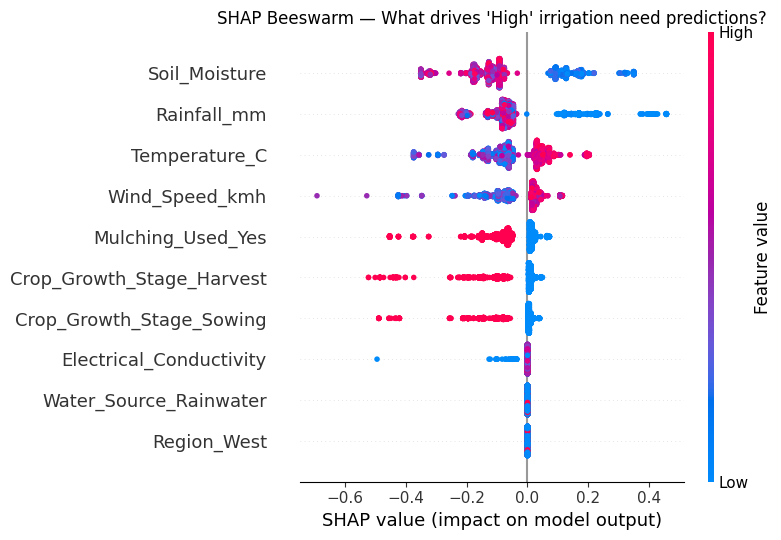

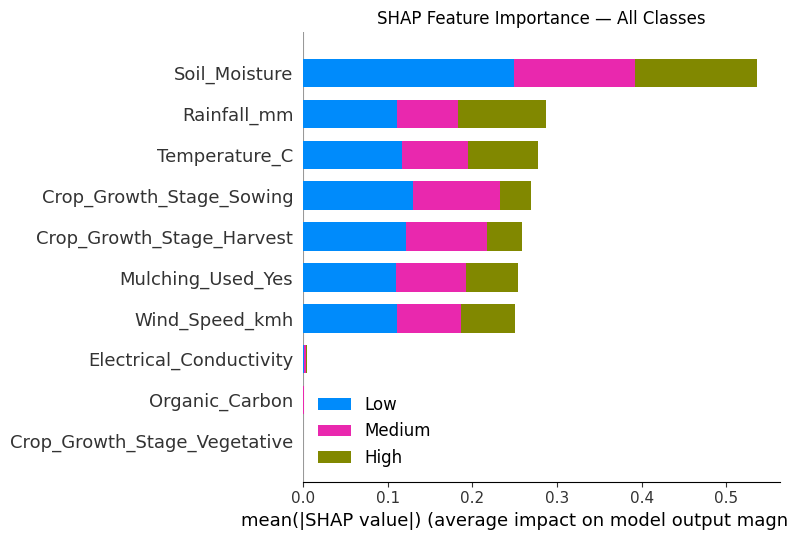

In [ ]:
import shap

shap.initjs()

best_tree = grid.best_estimator_.named_steps["model"]
explainer = shap.TreeExplainer(best_tree)

shap_values = explainer.shap_values(x_test)

# Beeswarm for High class
shap.summary_plot(
    shap_values[:, :, 0],              # all samples, all features, class "High"
    x_test,
    feature_names=list(x_train.columns),
    show=False,
    max_display = 10
)

plt.title("SHAP Beeswarm — What drives 'High' irrigation need predictions?")
plt.tight_layout()
plt.show()

# Bar chart for all classes
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=list(x_train.columns),
    plot_type="bar",
    class_names=["High", "Low", "Medium"],
    show=False,
    max_display = 10
)

plt.title("SHAP Feature Importance — All Classes")
plt.tight_layout()
plt.show()

SHAP beeswarm analysis for the High irrigation need class reveals a physically coherent decision structure: low soil moisture, low rainfall, high temperature, absence of mulching, and active growth stage (vegetative/flowering) are the primary drivers. Features that appeared uninformative in univariate EDA (Region, Irrigation_Type, Water_Source) are confirmed to have negligible SHAP contributions even when interactions are accounted for, closing the hypothesis loop opened during exploratory analysis. The alignment between model logic and established agronomic principles supports the model's potential for real-world deployment and generalization beyond the training data distribution.

# Summary and Conclusions

## Final Model

**DecisionTreeClassifier** with `max_depth=9`, `class_weight='balanced'`,
selected via Stratified 5-Fold GridSearchCV optimizing macro-F1.

## Key Findings

1. **Class weighting matters more than stratified folding** for this dataset.
   The 2×2 ablation on LogisticRegression showed that `class_weight='balanced'`
   nearly doubled High-class recall (0.44 → 0.85), while stratified K-Fold
   produced identical results to standard K-Fold — because the minority class,
   though only 3% by proportion, had sufficient absolute count (~50 per fold)
   for reliable representation under random splitting.

2. **Tree-based models dramatically outperform linear models** on this problem
   (macro-F1: 0.984 vs 0.676). The non-linear decision boundaries captured by
   DecisionTree are essential for modeling the interactions between soil,
   weather, and crop features.

3. **Model decisions are domain-consistent.** SHAP analysis confirms that
   predictions for High irrigation need are driven by low soil moisture,
   low rainfall, high temperature, absence of mulching, and active crop
   growth stage — all factors with established agronomic mechanisms. Features
   that appeared uninformative in univariate EDA (Region, Irrigation_Type,
   Water_Source) were confirmed to have negligible SHAP contributions.

4. **The model fails gracefully.** When the model misclassifies High-need
   fields (7.1% of cases), it predicts Medium — never Low. Errors degrade
   along the severity axis rather than catastrophically flipping.

## Limitations

- **Single DecisionTree is prone to overfitting.** The near-perfect test
  scores (99.6%+ on Low/Medium) warrant caution — a RandomForest ensemble
  would provide more robust generalization. The high test performance should
  be validated on truly held-out data from different seasons or regions.
- **No temporal validation.** Train/test split is random, not time-based.
  In production, the model would predict future irrigation needs based on
  past data — a temporal split would better simulate this.
- **One-hot encoding fragments categorical importance.** Crop_Growth_Stage's
  true importance is split across multiple dummy columns, making it appear
  less important than it may actually be in aggregate.

## Future Work

- **Threshold tuning** with precision-recall curves for the High class,
  selecting operating point based on explicit cost ratios
- **Ensemble models** (RandomForest, XGBoost) to reduce overfitting risk
  while maintaining interpretability through SHAP
- **Temporal cross-validation** to simulate real deployment conditions
- **Cost-sensitive evaluation** with explicit cost matrix
  (e.g., FN on High costs 10× more than FP)
- **Feature engineering** — interaction terms between Soil_Moisture ×
  Crop_Growth_Stage, cumulative rainfall over past N days
- **Aggregate categorical SHAP** — sum SHAP values across one-hot encoded
  dummies to get true categorical feature importance